# Adult Income Classification

**Problem type:** supervised binary classification.

This notebook predicts whether a person's annual income is `>50K` or `<=50K` using the
[UCI Adult (Census Income)](https://archive.ics.uci.edu/dataset/2/adult) dataset (Kohavi, 1996).
The goal is a complete, interpretable machine learning workflow—not maximizing accuracy.

**Primary model:** logistic regression in a scikit-learn `Pipeline`.
**Comparison model:** random forest (same preprocessing).


## 1. Environment check

Confirm that the core libraries required by the project environment are available.


In [1]:
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("sklearn", sklearn.__version__)
print("seaborn", sns.__version__)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


numpy 2.4.6
pandas 3.0.5
sklearn 1.9.0
seaborn 0.13.2


## 2. Load and inspect the dataset

The CSV combines the official UCI `adult.data` and `adult.test` files. Question marks in
the original files were stored as missing values. `income` is the target.


In [2]:
df = pd.read_csv("data/adult.csv")
print("Shape:", df.shape)
df.head()


Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       46043 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      46033 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  47985 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [4]:
print("Missing values:")
print(df.isna().sum())
print("\nTarget distribution:")
print(df["income"].value_counts())
print("\nTarget proportions:")
print(df["income"].value_counts(normalize=True).round(4))


Missing values:
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

Target distribution:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Target proportions:
income
<=50K    0.7607
>50K     0.2393
Name: proportion, dtype: float64


### Data quality notes

- Missing values appear in `workclass`, `occupation`, and `native-country`.
- The target is imbalanced: most records are `<=50K`. Accuracy alone would be misleading.
- `education` and `education-num` encode the same information (label vs. ordered years).
- `fnlwgt` is a census sampling weight, not an attribute of the person, so it is not used as a feature.


## 3. Data preparation and preprocessing

We drop `fnlwgt` and `education`, encode `income` as 1 for `>50K`, and split **before**
fitting transformers so that imputation, scaling, and one-hot encoding never leak test information.

- Numeric features: median imputation + `StandardScaler` (required for logistic regression).
- Categorical features: most-frequent imputation + one-hot encoding with unknown categories ignored.


In [5]:
TARGET = "income"
DROP_COLS = ["fnlwgt", "education"]

y = (df[TARGET] == ">50K").astype(int)
X = df.drop(columns=[TARGET] + DROP_COLS)

numeric_features = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_features = [c for c in X.columns if c not in numeric_features]

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)
print("Positive class rate:", y.mean().round(4))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])
print("Train positive rate:", y_train.mean().round(4))
print("Test positive rate:", y_test.mean().round(4))


Numeric: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Positive class rate: 0.2393
Train size: 39073 Test size: 9769
Train positive rate: 0.2393
Test positive rate: 0.2393


In [6]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)


## 4. Select and train models

Logistic regression is a standard model for binary classification. After one-hot encoding,
features are linear in the log-odds of the positive class, coefficients are interpretable,
and predicted probabilities support ROC analysis.

A random forest is trained with the same preprocessor as a nonlinear comparison. It can
capture interactions without explicit feature engineering, at the cost of harder interpretation.


In [7]:
logreg = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logreg.fit(X_train, y_train)
print("Logistic regression fitted.")


Logistic regression fitted.


In [8]:
rf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=20,
                n_jobs=-1,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

rf.fit(X_train, y_train)
print("Random forest fitted.")


Random forest fitted.


## 5. Evaluate model performance

Because about three quarters of people earn `<=50K`, a classifier that always predicts
the majority class would look strong on accuracy. Precision, recall, and F1 for the `>50K`
class, plus ROC-AUC, are therefore reported alongside accuracy.


In [9]:
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_>50K": precision_score(y_test, y_pred),
        "recall_>50K": recall_score(y_test, y_pred),
        "f1_>50K": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }
    print(name)
    print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))
    return metrics, y_pred, y_prob


log_metrics, y_pred_log, y_prob_log = evaluate(
    "Logistic Regression", logreg, X_test, y_test
)
rf_metrics, y_pred_rf, y_prob_rf = evaluate("Random Forest", rf, X_test, y_test)

metrics_table = pd.DataFrame([log_metrics, rf_metrics]).set_index("model").round(4)
metrics_table


Logistic Regression
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      7431
        >50K       0.57      0.84      0.67      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.82      0.77      9769
weighted avg       0.85      0.81      0.82      9769

Random Forest
              precision    recall  f1-score   support

       <=50K       0.94      0.82      0.88      7431
        >50K       0.59      0.85      0.70      2338

    accuracy                           0.82      9769
   macro avg       0.77      0.83      0.79      9769
weighted avg       0.86      0.82      0.83      9769



,accuracy,precision_>50K,recall_>50K,f1_>50K,roc_auc
model,,,,,
Logistic Regression,0.8069,0.5653,0.8366,0.6747,0.9037
Random Forest,0.8238,0.5924,0.8456,0.6967,0.9192


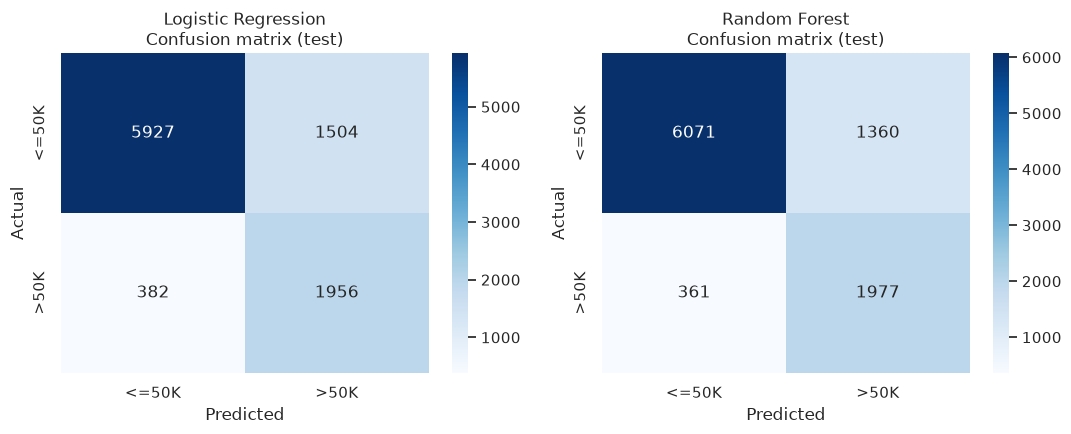

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, title, y_pred in [
    (axes[0], "Logistic Regression", y_pred_log),
    (axes[1], "Random Forest", y_pred_rf),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"],
        ax=ax,
    )
    ax.set_title(f"{title}\nConfusion matrix (test)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


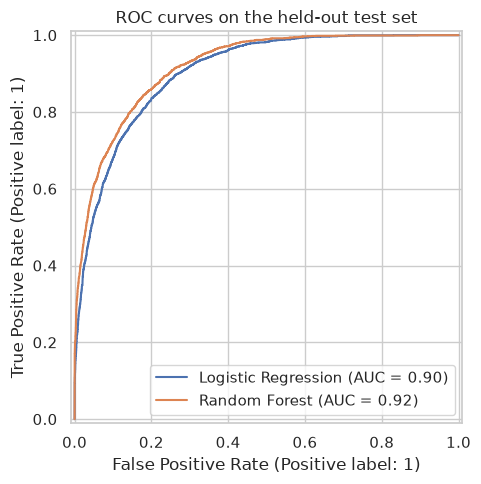

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(logreg, X_test, y_test, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_estimator(rf, X_test, y_test, name="Random Forest", ax=ax)
ax.set_title("ROC curves on the held-out test set")
plt.tight_layout()
plt.show()


### Subgroup metrics (fairness check)

Census income is historically associated with sex and race. Reporting F1 and recall by
group does not remove bias, but it makes disparate error rates visible instead of hiding
them in a single average.


In [12]:
def subgroup_table(y_true, y_pred, groups, min_n=50):
    rows = []
    for group_name, series in groups.items():
        for value in series.dropna().unique():
            mask = series == value
            n = int(mask.sum())
            if n < min_n:
                continue
            yt = y_true[mask]
            yp = y_pred[mask]
            rows.append(
                {
                    "group": group_name,
                    "value": value,
                    "n": n,
                    "positive_rate": yt.mean(),
                    "recall_>50K": recall_score(yt, yp, zero_division=0),
                    "f1_>50K": f1_score(yt, yp, zero_division=0),
                    "accuracy": accuracy_score(yt, yp),
                }
            )
    return pd.DataFrame(rows).sort_values(["group", "n"], ascending=[True, False]).round(4)


groups = {"sex": X_test["sex"], "race": X_test["race"]}
print("Logistic regression by subgroup")
display(subgroup_table(y_test, y_pred_log, groups))
print("Random forest by subgroup")
display(subgroup_table(y_test, y_pred_rf, groups))


Logistic regression by subgroup


,group,value,n,positive_rate,recall_>50K,f1_>50K,accuracy
2,race,White,8348,0.2538,0.8480,0.6806,0.7979
4,race,Black,944,0.1282,0.6529,0.6031,0.8898
5,race,Asian-Pac-Islander,304,0.2566,0.8590,0.6634,0.7763
6,race,Amer-Indian-Eskimo,104,0.0865,0.6667,0.4138,0.8365
3,race,Other,69,0.1594,0.6364,0.5833,0.8551
0,sex,Male,6480,0.3042,0.8661,0.6861,0.7590
1,sex,Female,3289,0.1116,0.6785,0.6058,0.9015


Random forest by subgroup


,group,value,n,positive_rate,recall_>50K,f1_>50K,accuracy
2,race,White,8348,0.2538,0.8561,0.7021,0.8156
4,race,Black,944,0.1282,0.7107,0.6466,0.9004
5,race,Asian-Pac-Islander,304,0.2566,0.8205,0.6882,0.8092
6,race,Amer-Indian-Eskimo,104,0.0865,0.6667,0.3750,0.8077
3,race,Other,69,0.1594,0.6364,0.5833,0.8551
0,sex,Male,6480,0.3042,0.8752,0.7047,0.7769
1,sex,Female,3289,0.1116,0.6866,0.6470,0.9164


### Coefficient snapshot (logistic regression)

The largest-magnitude coefficients indicate which (scaled or dummy) features most strongly
shift the log-odds of earning `>50K`. This is an association in the fitted model, not a
causal claim.


In [13]:
feature_names = logreg.named_steps["preprocess"].get_feature_names_out()
coefs = logreg.named_steps["model"].coef_[0]
coef_df = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefs})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .head(15)
    .round(3)
)
coef_df


,feature,coefficient
2,num__capital-gain,2.284
28,cat__occupation_Priv-house-serv,-1.949
14,cat__marital-status_Married-AF-spouse,1.647
15,cat__marital-status_Married-civ-spouse,1.507
50,cat__native-country_Columbia,-1.324
81,cat__native-country_South,-1.287
17,cat__marital-status_Never-married,-1.122
39,cat__relationship_Wife,0.987
47,cat__native-country_Cambodia,0.933
37,cat__relationship_Own-child,-0.903


## 6. Notebook summary

This project is a supervised classification task: predict whether census respondents earn
more than $50,000 a year from demographic and employment attributes in the UCI Adult dataset.
A logistic regression pipeline (median/most-frequent imputation, scaling, and one-hot encoding)
was trained with class weighting to address imbalance; a random forest with the same preprocessor
served as a nonlinear comparison. Evaluation on a stratified 20% test set used accuracy together
with precision, recall, F1 for the `>50K` class, ROC-AUC, confusion matrices, and ROC curves,
because a majority-class baseline would inflate accuracy. Subgroup metrics by sex and race show
that error rates are not uniform, which is a limitation of both the historical census process
and of using sensitive attributes as features. The workflow is designed for interpretation and
responsible reporting rather than for production scoring.
